# Text Classification with RNNs

**Objective:** Implement and compare Vanilla RNN, LSTM, and GRU for binary sentiment classification on IMDB.

---

## Architecture Overview

Each model shares an identical structure except for the recurrent layer:

```
Embedding(10000, 100) → Dropout(0.3) → Bidirectional RNN/LSTM/GRU(128)
  → Dropout(0.3) → Linear(256→1) → Sigmoid
```
> Note: Bidirectional doubles the hidden dimension output (128×2 = 256), so the FC layer input is 256.

## 1. Install & Import Dependencies

In [9]:
# Uncomment if needed
# !pip install torch torchtext tensorflow scikit-learn matplotlib seaborn pandas

In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import time
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {device}")

PyTorch  : 2.7.0+cu118
NumPy    : 2.2.3
Device   : cuda


## 2. Hyperparameters

> `MAX_LEN` is set to **128** to help Vanilla RNN propagate gradients. `PATIENCE` controls early stopping.

In [11]:
# ── Fixed (per task spec) ──────────────────────────────────────────
VOCAB_SIZE    = 10_000
EMBED_DIM     = 100
HIDDEN_DIM    = 128
NUM_LAYERS    = 1
BATCH_SIZE    = 64
LR            = 0.001
EPOCHS        = 20       # max epochs; early stopping halts sooner
MAX_LEN       = 128      # reduced to help Vanilla RNN propagate gradients

# ── Regularisation — per model ────────────────────────────────────
# RNN needs stronger dropout; LSTM/GRU are fine at 0.3
DROPOUT_CONFIG = {
    'RNN' : 0.5,   # stronger — RNN overfits late with sharp val loss spike
    'LSTM': 0.3,
    'GRU' : 0.3,
}
# L2 weight decay — only applied to RNN to curb late-stage overfitting
WEIGHT_DECAY_CONFIG = {
    'RNN' : 1e-4,
    'LSTM': 0.0,
    'GRU' : 0.0,
}
# Early stopping patience — RNN gets tighter patience (stops faster on spike)
PATIENCE_CONFIG = {
    'RNN' : 2,
    'LSTM': 3,
    'GRU' : 3,
}

# ── Shared knobs ──────────────────────────────────────────────────
BIDIRECTIONAL = True
LR_FACTOR     = 0.5
LR_PATIENCE   = 2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# FC input size doubles when bidirectional
FC_INPUT = HIDDEN_DIM * 2 if BIDIRECTIONAL else HIDDEN_DIM
print(f"FC input dim : {FC_INPUT}  (bidirectional={BIDIRECTIONAL})")
print("Hyperparameters set.")

FC input dim : 256  (bidirectional=True)
Hyperparameters set.


## 3. Dataset Preparation

Steps:
1. Load IMDB via `keras.datasets` (fallback: `torchtext`)
2. Build vocabulary — top 10,000 words
3. Convert text → integer sequences
4. Pad / truncate to `MAX_LEN = 128`
5. Wrap in `DataLoader`

In [12]:
def load_imdb():
    """Load IMDB via keras (fast) or torchtext (fallback)."""
    try:
        from tensorflow.keras.datasets import imdb as keras_imdb
        print("Loading IMDB via keras.datasets ...")
        (x_train, y_train), (x_test, y_test) = keras_imdb.load_data(num_words=VOCAB_SIZE)

        def pad_trunc(seqs, maxlen):
            out = np.zeros((len(seqs), maxlen), dtype=np.int64)
            for i, s in enumerate(seqs):
                s = list(s)[:maxlen]
                out[i, :len(s)] = s
            return out

        return (pad_trunc(x_train, MAX_LEN), np.array(y_train, dtype=np.float32),
                pad_trunc(x_test,  MAX_LEN), np.array(y_test,  dtype=np.float32))
    except Exception as e:
        print(f"keras unavailable ({e}), trying torchtext ...")
        return load_imdb_torchtext()


def tokenize(text):
    text = re.sub(r"<[^>]+>", " ", text.lower())
    return re.sub(r"[^a-z0-9\s]", "", text).split()


def load_imdb_torchtext():
    from torchtext.datasets import IMDB
    print("Loading IMDB via torchtext ...")

    def collect(it):
        labels, texts = [], []
        for label, text in it:
            labels.append(1 if label == 'pos' else 0)
            texts.append(tokenize(text))
        return texts, labels

    train_texts, train_labels = collect(IMDB(split='train'))
    test_texts,  test_labels  = collect(IMDB(split='test'))

    counter = Counter(tok for sent in train_texts for tok in sent)
    vocab   = {w: i+2 for i, (w, _) in enumerate(counter.most_common(VOCAB_SIZE-2))}
    vocab['<PAD>'] = 0;  vocab['<UNK>'] = 1

    def encode(texts):
        arr = np.zeros((len(texts), MAX_LEN), dtype=np.int64)
        for i, sent in enumerate(texts):
            ids = [vocab.get(t, 1) for t in sent[:MAX_LEN]]
            arr[i, :len(ids)] = ids
        return arr

    return (encode(train_texts), np.array(train_labels, dtype=np.float32),
            encode(test_texts),  np.array(test_labels,  dtype=np.float32))


x_train, y_train, x_test, y_test = load_imdb()
print(f"Train : {len(y_train)} samples")
print(f"Test  : {len(y_test)}  samples")
print(f"Shape : {x_train.shape}")

Loading IMDB via keras.datasets ...
Train : 25000 samples
Test  : 25000  samples
Shape : (25000, 128)


In [13]:
class IMDBDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]


train_loader = DataLoader(IMDBDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(IMDBDataset(x_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 391
Test  batches : 391


## 4. Model Architecture

**Design choices:**
- `nn.Dropout` applied after the embedding layer — rate is **per model** (RNN: 0.5, LSTM/GRU: 0.3)
- `bidirectional=True` — processes sequences in both directions, doubling representation capacity
- `nn.Dropout` applied to the final hidden state before the FC layer
- FC input adjusted to `HIDDEN_DIM * 2` (= 256) to account for concatenated forward + backward states

In [14]:
class SentimentClassifier(nn.Module):
    """
    Bidirectional RNN/LSTM/GRU classifier with dropout regularisation.

    Flow:
        Embedding → Dropout → BiRNN → Dropout → Linear(256→1) → Sigmoid
    """
    def __init__(self, rnn_type: str):
        super().__init__()
        self.rnn_type = rnn_type.upper()
        dropout = DROPOUT_CONFIG[self.rnn_type]   # per-model dropout rate

        self.embedding     = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.embed_dropout = nn.Dropout(dropout)

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[self.rnn_type]
        self.rnn = rnn_cls(
            input_size    = EMBED_DIM,
            hidden_size   = HIDDEN_DIM,
            num_layers    = NUM_LAYERS,
            batch_first   = True,
            bidirectional = BIDIRECTIONAL,
        )
        self.fc_dropout = nn.Dropout(dropout)
        self.fc         = nn.Linear(FC_INPUT, 1)   # 256 → 1
        self.sigmoid    = nn.Sigmoid()

    def forward(self, x):
        emb = self.embed_dropout(self.embedding(x))       # (B, T, E)
        _, hidden = self.rnn(emb)

        if self.rnn_type == 'LSTM':
            h = hidden[0]                                 # (num_layers*2, B, H)
        else:
            h = hidden                                    # (num_layers*2, B, H)

        # Concatenate final forward and backward hidden states
        if BIDIRECTIONAL:
            h = torch.cat([h[-2], h[-1]], dim=1)          # (B, 2H)
        else:
            h = h[-1]                                     # (B, H)

        h = self.fc_dropout(h)
        return self.sigmoid(self.fc(h)).squeeze(1)


# Sanity check
for name in ['RNN', 'LSTM', 'GRU']:
    m      = SentimentClassifier(name)
    dummy  = torch.zeros(4, MAX_LEN, dtype=torch.long)
    out    = m(dummy)
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:4s} | dropout: {DROPOUT_CONFIG[name]}  weight_decay: {WEIGHT_DECAY_CONFIG[name]}  "
          f"patience: {PATIENCE_CONFIG[name]}  | output: {out.shape} | params: {params:,}")

RNN  | dropout: 0.5  weight_decay: 0.0001  patience: 2  | output: torch.Size([4]) | params: 1,059,137
LSTM | dropout: 0.3  weight_decay: 0.0  patience: 3  | output: torch.Size([4]) | params: 1,235,777
GRU  | dropout: 0.3  weight_decay: 0.0  patience: 3  | output: torch.Size([4]) | params: 1,176,897


## 5. Training Helpers

- `EarlyStopping` — halts training when val loss doesn't improve for `patience` epochs, then restores best weights
- `ReduceLROnPlateau` — halves the learning rate after 2 epochs of no val loss improvement

In [15]:
class EarlyStopping:
    """Stops training when val_loss stops improving. Saves best weights."""
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None
        self.stop       = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        model.load_state_dict({k: v.to(device) for k, v in self.best_state.items()})


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += ((pred >= 0.5).float() == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y      = x.to(device), y.to(device)
        pred      = model(x)
        loss      = criterion(pred, y)
        total_loss += loss.item() * len(y)
        preds_bin  = (pred >= 0.5).long().cpu().numpy()
        labels     = y.long().cpu().numpy()
        correct   += (preds_bin == labels).sum()
        total     += len(y)
        all_preds.extend(preds_bin)
        all_labels.extend(labels)
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels):
    return {
        'accuracy' : (preds == labels).mean(),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall'   : recall_score(labels, preds, zero_division=0),
        'f1'       : f1_score(labels, preds, zero_division=0),
        'confusion': confusion_matrix(labels, preds),
    }

print("Helpers defined.")

Helpers defined.


## 6. Train All Three Models

> Each model uses its own early stopping patience and weight decay. RNN uses patience=2 and weight_decay=1e-4 to catch its late-stage val loss spike quickly.

In [16]:
criterion = nn.BCELoss()
results   = {}
history   = {}

for rnn_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n{'='*65}")
    print(f"  Training Bidirectional {rnn_type} Classifier")
    print(f"  dropout={DROPOUT_CONFIG[rnn_type]}  weight_decay={WEIGHT_DECAY_CONFIG[rnn_type]}  patience={PATIENCE_CONFIG[rnn_type]}")
    print(f"{'='*65}")

    model     = SentimentClassifier(rnn_type).to(device)
    optimizer = torch.optim.Adam(
                    model.parameters(),
                    lr           = LR,
                    weight_decay = WEIGHT_DECAY_CONFIG[rnn_type]  # L2 reg for RNN
                )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=LR_FACTOR,
                    patience=LR_PATIENCE)
    stopper   = EarlyStopping(patience=PATIENCE_CONFIG[rnn_type])
    epoch_hist = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': [], 'lr': []}

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc       = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, test_loader, criterion)
        elapsed               = time.time() - t0
        current_lr            = optimizer.param_groups[0]['lr']

        epoch_hist['tr_loss'].append(tr_loss)
        epoch_hist['tr_acc'].append(tr_acc)
        epoch_hist['va_loss'].append(va_loss)
        epoch_hist['va_acc'].append(va_acc)
        epoch_hist['lr'].append(current_lr)

        scheduler.step(va_loss)
        stopper.step(va_loss, model)

        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  "
              f"Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}  "
              f"LR: {current_lr:.6f}  ({elapsed:.1f}s)"
              f"{'  ← best' if stopper.counter == 0 else ''}")

        if stopper.stop:
            print(f"  Early stopping triggered at epoch {epoch}.")
            break

    stopper.restore(model)
    _, _, preds, labels = evaluate(model, test_loader, criterion)
    results[rnn_type]   = compute_metrics(preds, labels)
    history[rnn_type]   = epoch_hist

    m = results[rnn_type]
    print(f"\n  ✓ Best Val Loss : {stopper.best_loss:.4f}")
    print(f"  Test Accuracy   : {m['accuracy']:.4f}")
    print(f"  Precision       : {m['precision']:.4f}")
    print(f"  Recall          : {m['recall']:.4f}")
    print(f"  F1-Score        : {m['f1']:.4f}")

print("\n✓ All models trained!")


  Training Bidirectional RNN Classifier
  dropout=0.5  weight_decay=0.0001  patience=2
  Epoch  1/20  Train Loss: 0.7017  Acc: 0.5155  |  Val Loss: 0.6811  Acc: 0.5648  LR: 0.001000  (2.2s)  ← best
  Epoch  2/20  Train Loss: 0.6865  Acc: 0.5516  |  Val Loss: 0.6794  Acc: 0.5696  LR: 0.001000  (1.9s)  ← best
  Epoch  3/20  Train Loss: 0.6792  Acc: 0.5727  |  Val Loss: 0.6910  Acc: 0.5313  LR: 0.001000  (1.8s)
  Epoch  4/20  Train Loss: 0.6762  Acc: 0.5807  |  Val Loss: 0.6590  Acc: 0.6247  LR: 0.001000  (1.8s)  ← best
  Epoch  5/20  Train Loss: 0.6699  Acc: 0.5991  |  Val Loss: 0.6724  Acc: 0.6058  LR: 0.001000  (1.8s)
  Epoch  6/20  Train Loss: 0.6671  Acc: 0.5992  |  Val Loss: 0.6319  Acc: 0.6579  LR: 0.001000  (1.8s)  ← best
  Epoch  7/20  Train Loss: 0.6546  Acc: 0.6206  |  Val Loss: 0.6838  Acc: 0.5814  LR: 0.001000  (1.8s)
  Epoch  8/20  Train Loss: 0.6465  Acc: 0.6405  |  Val Loss: 0.6088  Acc: 0.6850  LR: 0.001000  (1.8s)  ← best
  Epoch  9/20  Train Loss: 0.6456  Acc: 0.6336  

## 7. Results — Comparison Table

In [17]:
rows = []
for name, m in results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(float(m['accuracy']),  4),
        'Precision': round(float(m['precision']), 4),
        'Recall'   : round(float(m['recall']),    4),
        'F1-Score' : round(float(m['f1']),        4),
        'Epochs Ran': len(history[name]['tr_loss']),
    })

df = pd.DataFrame(rows).set_index('Model')
print("\n===== COMPARISON SUMMARY =====")
print(df.to_string())

best = df['F1-Score'].idxmax()
print(f"\nBest model by F1-Score: {best} ({df.loc[best,'F1-Score']:.4f})")


===== COMPARISON SUMMARY =====
       Accuracy  Precision  Recall  F1-Score  Epochs Ran
Model                                                   
RNN      0.6850     0.6910  0.6694    0.6800          10
LSTM     0.8378     0.8383  0.8371    0.8377          13
GRU      0.8382     0.8317  0.8482    0.8398           9

Best model by F1-Score: GRU (0.8398)


## 8. Visualisations

### 8a. Training Curves

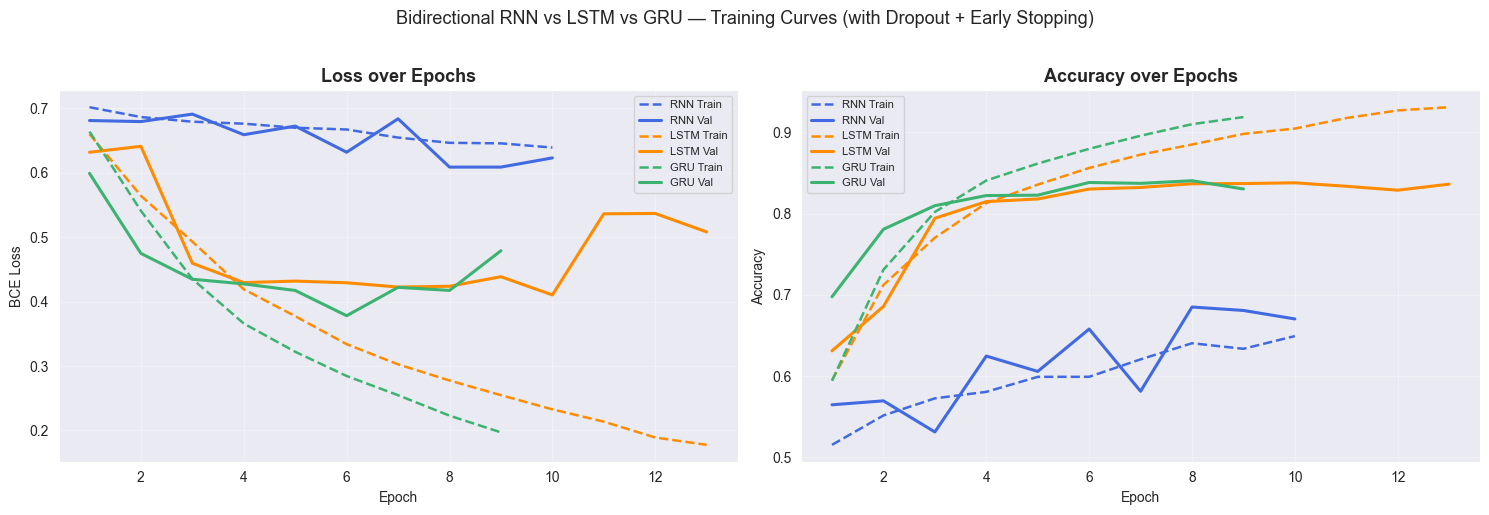

In [18]:
colors = {'RNN': 'royalblue', 'LSTM': 'darkorange', 'GRU': 'mediumseagreen'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, hist in history.items():
    c = colors[name]
    ep = range(1, len(hist['tr_loss']) + 1)
    axes[0].plot(ep, hist['tr_loss'], label=f"{name} Train", color=c, linestyle='--', linewidth=1.8)
    axes[0].plot(ep, hist['va_loss'], label=f"{name} Val",   color=c, linewidth=2.2)
    axes[1].plot(ep, hist['tr_acc'],  label=f"{name} Train", color=c, linestyle='--', linewidth=1.8)
    axes[1].plot(ep, hist['va_acc'],  label=f"{name} Val",   color=c, linewidth=2.2)

axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=8);   axes[0].grid(alpha=0.3)

axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8);   axes[1].grid(alpha=0.3)

plt.suptitle('Bidirectional RNN vs LSTM vs GRU — Training Curves (with Dropout + Early Stopping)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8c. Confusion Matrices

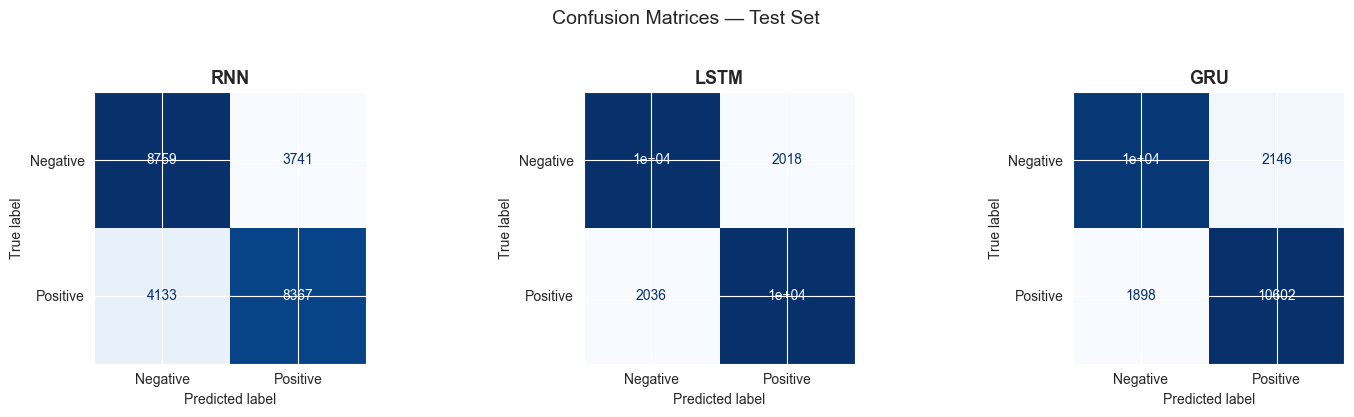

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, m) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=m['confusion'],
        display_labels=['Negative', 'Positive']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 8d. Metric Bar Chart

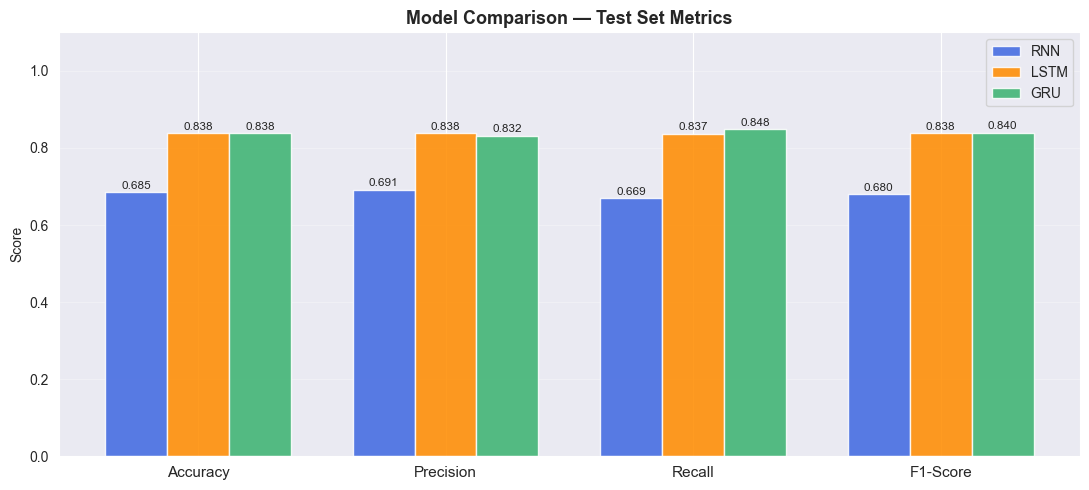

In [21]:
metrics_keys  = ['accuracy', 'precision', 'recall', 'f1']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(colors.items()):
    vals = [float(results[name][k]) for k in metrics_keys]
    bars = ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.87)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8e. Train vs Val Accuracy Gap (Overfit Monitor)

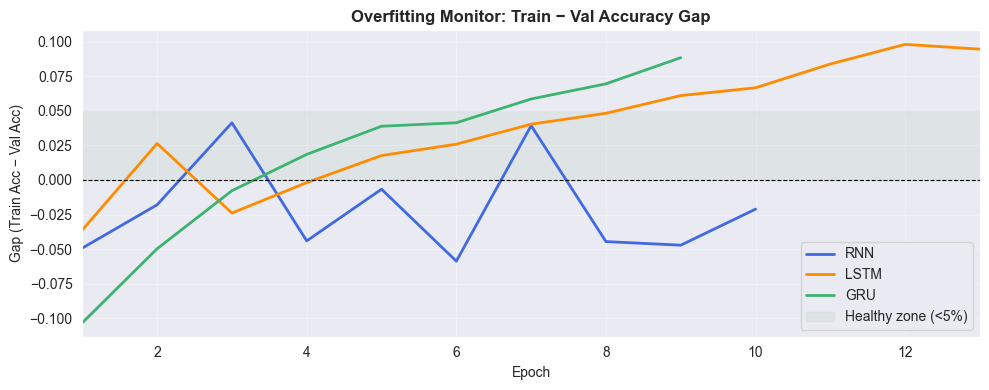


Final train-val accuracy gaps:
  RNN: -0.0211
  LSTM: +0.0946
  GRU: +0.0885


In [22]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, hist in history.items():
    ep  = range(1, len(hist['tr_acc']) + 1)
    gap = [tr - va for tr, va in zip(hist['tr_acc'], hist['va_acc'])]
    ax.plot(ep, gap, label=name, color=colors[name], linewidth=2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(range(1, EPOCHS+1), 0, 0.05, alpha=0.05, color='green', label='Healthy zone (<5%)')
ax.set_title('Overfitting Monitor: Train − Val Accuracy Gap', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch');  ax.set_ylabel('Gap (Train Acc − Val Acc)')
ax.legend();             ax.grid(alpha=0.3)
ax.set_xlim(1, max(len(h['tr_acc']) for h in history.values()))
plt.tight_layout()
plt.show()

print("\nFinal train-val accuracy gaps:")
for name, hist in history.items():
    gap = hist['tr_acc'][-1] - hist['va_acc'][-1]
    print(f"  {name}: {gap:+.4f}")